In [3]:
import pandas as pd

In [4]:
df=pd.read_csv('/content/depression_anxiety_data.csv')
df.head()

,id,school_year,age,gender,bmi,who_bmi,phq_score,depression_severity,depressiveness,suicidal,depression_diagnosis,depression_treatment,gad_score,anxiety_severity,anxiousness,anxiety_diagnosis,anxiety_treatment,epworth_score,sleepiness
0,1,1,19,male,33.333333,Class I Obesity,9,Mild,False,False,False,False,11,Moderate,True,False,False,7.0,False
1,2,1,18,male,19.841270,Normal,8,Mild,False,False,False,False,5,Mild,False,False,False,14.0,True
2,3,1,19,male,25.102391,Overweight,8,Mild,False,False,False,False,6,Mild,False,False,False,6.0,False
3,4,1,18,female,23.738662,Normal,19,Moderately severe,True,True,False,False,15,Severe,True,False,False,11.0,True
4,5,1,18,male,25.617284,Overweight,6,Mild,False,False,False,False,14,Moderate,True,False,False,3.0,False


In [5]:
df.shape

(783, 19)

In [6]:
df.columns

Index(['id', 'school_year', 'age', 'gender', 'bmi', 'who_bmi', 'phq_score',
       'depression_severity', 'depressiveness', 'suicidal',
       'depression_diagnosis', 'depression_treatment', 'gad_score',
       'anxiety_severity', 'anxiousness', 'anxiety_diagnosis',
       'anxiety_treatment', 'epworth_score', 'sleepiness'],
      dtype='object')

In [7]:
df.dtypes

,0
id,int64
school_year,int64
age,int64
gender,object
bmi,float64
who_bmi,object
phq_score,int64
depression_severity,object
depressiveness,object
suicidal,object


In [8]:
df.isna().sum()

,0
id,0
school_year,0
age,0
gender,0
bmi,0
who_bmi,0
phq_score,0
depression_severity,4
depressiveness,3
suicidal,1


In [9]:
features = ['phq_score','gad_score','age','bmi','epworth_score','gender']
cluster_df = df[features].copy()
cluster_df.head()

,phq_score,gad_score,age,bmi,epworth_score,gender
0,9,11,19,33.333333,7.0,male
1,8,5,18,19.841270,14.0,male
2,8,6,19,25.102391,6.0,male
3,19,15,18,23.738662,11.0,female
4,6,14,18,25.617284,3.0,male


In [10]:
cluster_df = cluster_df.dropna()
print("Shape after dropping nulls:", cluster_df.shape)

Shape after dropping nulls: (775, 6)


In [11]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
cluster_df['gender'] = le.fit_transform(cluster_df['gender'])

In [12]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(cluster_df)

In [13]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

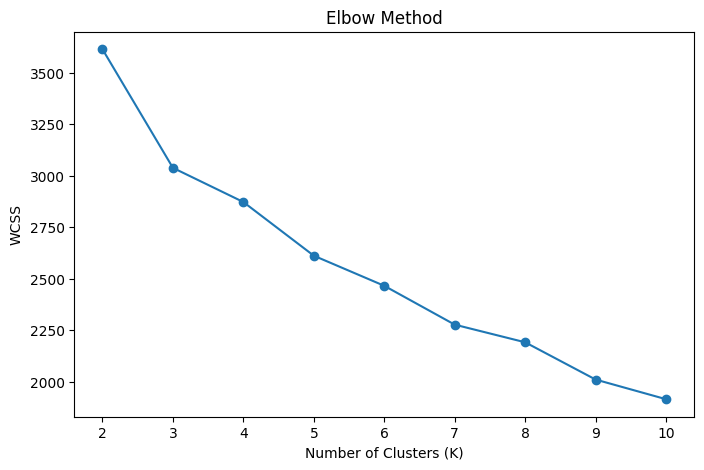

In [14]:
wcss = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)
plt.figure(figsize=(8,5))
plt.plot(range(2,11), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.savefig('elbow_method.png', dpi=150, bbox_inches='tight')
plt.show()

K = 4 | Silhouette Score = 0.1928
K = 5 | Silhouette Score = 0.1944
K = 6 | Silhouette Score = 0.2014




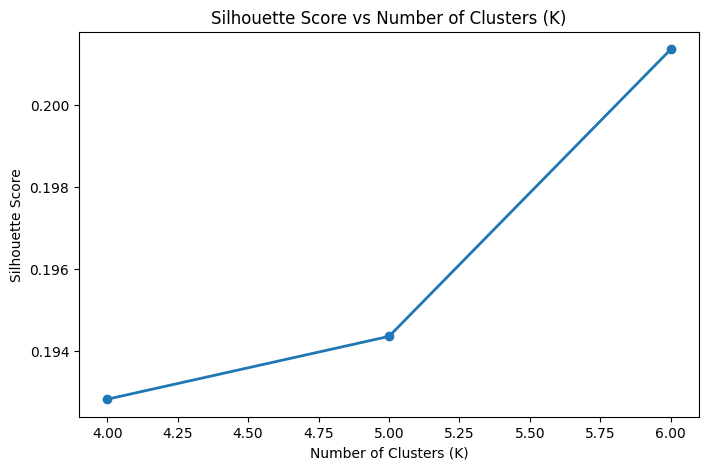

In [15]:
silhouette_scores = []
k_values = range(4, 7)
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    cluster_labels = kmeans.fit_predict(scaled_data)
    score = silhouette_score(scaled_data, cluster_labels)
    silhouette_scores.append(score)
    print(f"K = {k} | Silhouette Score = {round(score,4)}")
print("\n")
plt.figure(figsize=(8,5))
plt.plot(
    k_values,
    silhouette_scores,
    marker='o',
    linewidth=2
)
plt.title('Silhouette Score vs Number of Clusters (K)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
# plt.grid(alpha=0.3)
plt.savefig('silhouette_score.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
best_k = 6
kmeans = KMeans(n_clusters=best_k, random_state=42)
cluster_labels = kmeans.fit_predict(scaled_data)

In [17]:
cluster_df['Cluster'] = cluster_labels
cluster_df.head()

,phq_score,gad_score,age,bmi,epworth_score,gender,Cluster
0,9,11,19,33.333333,7.0,1,1
1,8,5,18,19.841270,14.0,1,2
2,8,6,19,25.102391,6.0,1,0
3,19,15,18,23.738662,11.0,0,4
4,6,14,18,25.617284,3.0,1,0


In [18]:
cluster_df['Cluster'].value_counts()

,count
Cluster,
0,259
5,186
2,167
3,61
1,56
4,46


In [19]:
cluster_profiles = cluster_df.groupby('Cluster').mean()
cluster_profiles

,phq_score,gad_score,age,bmi,epworth_score,gender
Cluster,,,,,,
0,4.810811,4.301158,19.915058,23.855864,4.857143,1.000000
1,8.750000,7.303571,19.892857,31.339336,5.553571,0.285714
2,10.125749,10.976048,19.730539,22.217162,8.610778,0.197605
3,6.622951,5.983607,23.885246,25.398009,6.590164,0.737705
4,17.173913,16.152174,20.065217,24.481994,13.130435,0.456522
5,4.924731,4.521505,20.134409,20.582302,4.994624,0.016129


In [20]:
cluster_profiles = cluster_profiles.round(2)
cluster_profiles

,phq_score,gad_score,age,bmi,epworth_score,gender
Cluster,,,,,,
0,4.81,4.30,19.92,23.86,4.86,1.00
1,8.75,7.30,19.89,31.34,5.55,0.29
2,10.13,10.98,19.73,22.22,8.61,0.20
3,6.62,5.98,23.89,25.40,6.59,0.74
4,17.17,16.15,20.07,24.48,13.13,0.46
5,4.92,4.52,20.13,20.58,4.99,0.02


In [21]:
cluster_profiles['count'] = cluster_df['Cluster'].value_counts().sort_index().values

In [22]:
def phq_severity(score):
    if score <= 4:
        return "Minimal"
    elif score <= 9:
        return "Mild"
    elif score <= 14:
        return "Moderate"
    else:
        return "Severe"
cluster_profiles['PHQ_Severity'] = cluster_profiles['phq_score'].apply(phq_severity)

In [23]:
def gad_severity(score):
    if score <= 4:
        return "Minimal"
    elif score <= 9:
        return "Mild"
    elif score <= 14:
        return "Moderate"
    else:
        return "Severe"
cluster_profiles['GAD_Severity'] = cluster_profiles['gad_score'].apply(gad_severity)

In [24]:
cluster_profiles['Profile_Name'] = [
    "Low-Risk Male Group",
    "Obesity-Associated Mild Distress",
    "Moderate Anxiety-Depression with Sleep Issues",
    "Older Adult Mild Distress Group",
    "High-Risk Severe Anxiety & Depression",
    "Low-Risk Healthy Female Group"
]


In [25]:
cluster_df.to_csv("clustered_patients.csv", index=False)

In [26]:
cluster_profiles.to_csv("cluster_profiles.csv")

In [27]:
df=pd.read_csv('/content/cluster_profiles.csv')
df

,Cluster,phq_score,gad_score,age,bmi,epworth_score,gender,count,PHQ_Severity,GAD_Severity,Profile_Name
0,0,4.81,4.30,19.92,23.86,4.86,1.00,259,Mild,Mild,Low-Risk Male Group
1,1,8.75,7.30,19.89,31.34,5.55,0.29,56,Mild,Mild,Obesity-Associated Mild Distress
2,2,10.13,10.98,19.73,22.22,8.61,0.20,167,Moderate,Moderate,Moderate Anxiety-Depression with Sleep Issues
3,3,6.62,5.98,23.89,25.40,6.59,0.74,61,Mild,Mild,Older Adult Mild Distress Group
4,4,17.17,16.15,20.07,24.48,13.13,0.46,46,Severe,Severe,High-Risk Severe Anxiety & Depression
5,5,4.92,4.52,20.13,20.58,4.99,0.02,186,Mild,Mild,Low-Risk Healthy Female Group


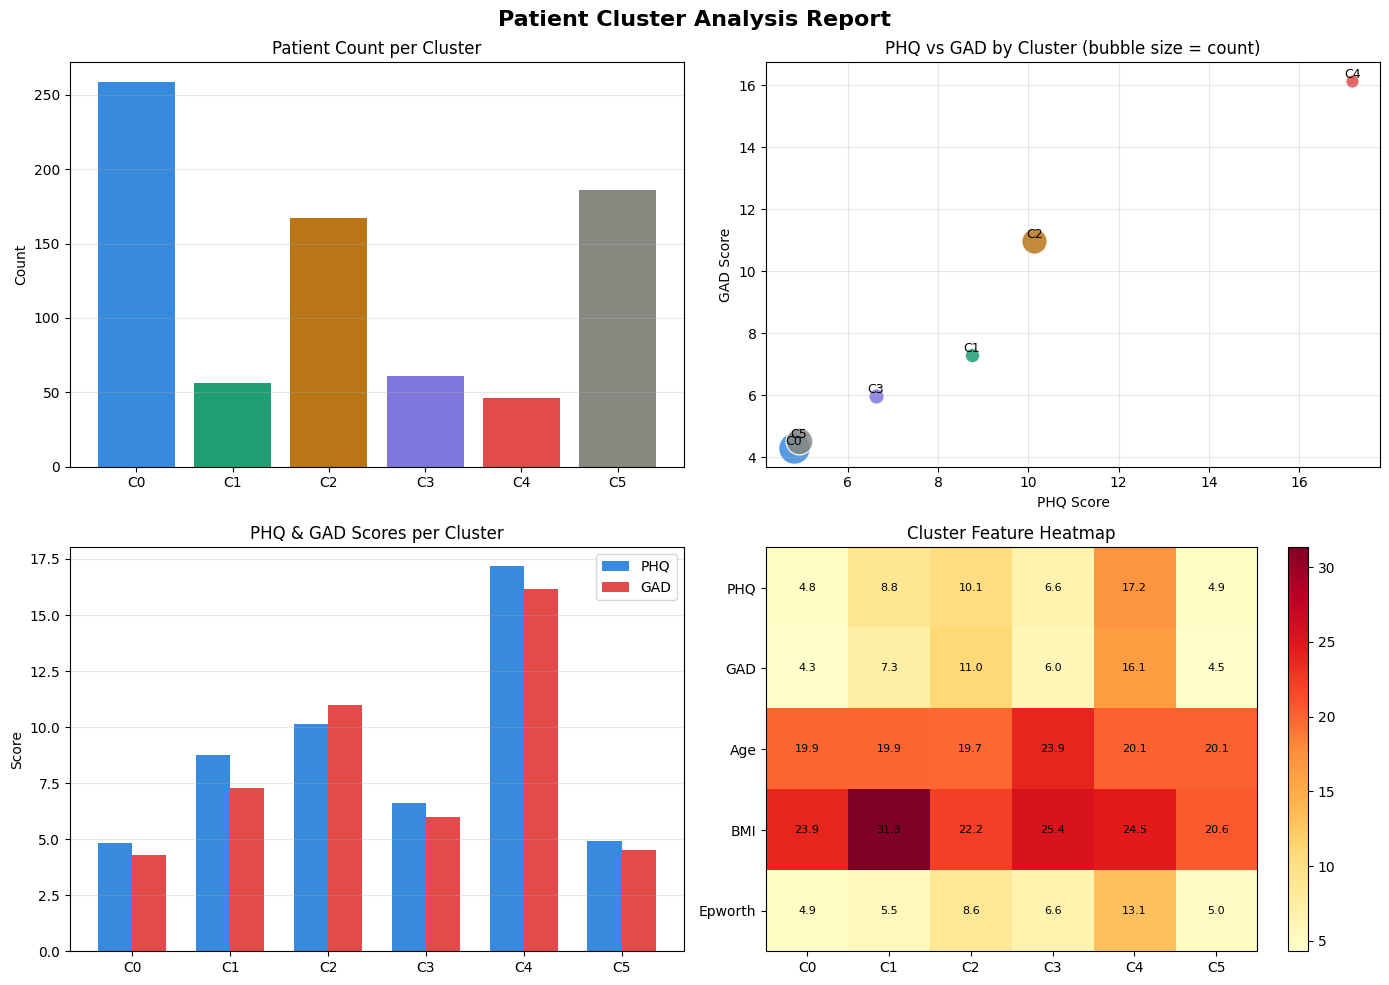

In [28]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
cluster_colors = ['#378ADD','#1D9E75','#BA7517','#7F77DD','#E24B4A','#888780']
cluster_names = [
    'C0: Low-Risk Male Group', 'C1: Obesity Distress',
    'C2: Moderate Mixed', 'C3: Older Mild',
    'C4: High-Risk Severe', 'C5: Low-Risk Female Gorup'
]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Patient Cluster Analysis Report', fontsize=16, fontweight='bold')
# Plot 1 — Patient count per cluster
axes[0,0].bar(range(6), cluster_profiles['count'], color=cluster_colors, edgecolor='none')
axes[0,0].set_title('Patient Count per Cluster')
axes[0,0].set_xticks(range(6))
axes[0,0].set_xticklabels([f'C{i}' for i in range(6)])
axes[0,0].set_ylabel('Count')
axes[0,0].grid(axis='y', alpha=0.3)
# Plot 2 — PHQ vs GAD scatter
for i in range(6):
    axes[0,1].scatter(
        cluster_profiles.loc[i,'phq_score'],
        cluster_profiles.loc[i,'gad_score'],
        s=cluster_profiles.loc[i,'count']*2,
        color=cluster_colors[i], label=f'C{i}', alpha=0.85, edgecolors='white'
    )
    axes[0,1].annotate(f'C{i}',
        (cluster_profiles.loc[i,'phq_score'], cluster_profiles.loc[i,'gad_score']),
        fontsize=9, ha='center', va='bottom')
axes[0,1].set_title('PHQ vs GAD by Cluster (bubble size = count)')
axes[0,1].set_xlabel('PHQ Score')
axes[0,1].set_ylabel('GAD Score')
axes[0,1].grid(alpha=0.3)
# Plot 3 — Grouped bar: PHQ & GAD per cluster
x = np.arange(6)
w = 0.35
axes[1,0].bar(x - w/2, cluster_profiles['phq_score'], w, label='PHQ', color='#378ADD', edgecolor='none')
axes[1,0].bar(x + w/2, cluster_profiles['gad_score'], w, label='GAD', color='#E24B4A', edgecolor='none')
axes[1,0].set_title('PHQ & GAD Scores per Cluster')
axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels([f'C{i}' for i in range(6)])
axes[1,0].set_ylabel('Score')
axes[1,0].legend()
axes[1,0].grid(axis='y', alpha=0.3)
# Plot 4 — Heatmap
heatmap_data = cluster_profiles[['phq_score','gad_score','age','bmi','epworth_score']].values.T
im = axes[1,1].imshow(heatmap_data, cmap='YlOrRd', aspect='auto')
axes[1,1].set_xticks(range(6))
axes[1,1].set_xticklabels([f'C{i}' for i in range(6)])
axes[1,1].set_yticks(range(5))
axes[1,1].set_yticklabels(['PHQ','GAD','Age','BMI','Epworth'])
axes[1,1].set_title('Cluster Feature Heatmap')
for i in range(5):
    for j in range(6):
        axes[1,1].text(j, i, f'{heatmap_data[i,j]:.1f}', ha='center', va='center', fontsize=8)
plt.colorbar(im, ax=axes[1,1])
plt.tight_layout()
plt.savefig('cluster_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()